## Notebook Setup

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
import types
import sys
import os
import json
import joblib
from pathlib import Path


from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from numpy import float64
from sklearn.metrics import roc_auc_score
from utils.metrics.calculate_metric import calculate_agg_metric
from utils.set_random_seed import set_random_seed
# from interpret.glassbox import ExplainableBoostingClassifier
from utils.model_loaders import load_logistic_models_for_subfolder



set_random_seed(42)
EXPERIMENTS = ["experiment_1", "experiment_4", "experiment_54", "experiment_61", "experiment_73"]

INFO 03-09 15:57:24 [__init__.py:216] Automatically detected platform cuda.


In [7]:
## Load best param


best_params = {
    "judge": [],
    "groundtruth": []
}

for f in sorted(os.listdir("best_params")):
    _params = []
    results = json.load(open(f"best_params/{f}", "r"))["results"]
    for p in results:
        try:
            _params.append(p["best_params"])
        except KeyError:
            _params.append(None)
    
    if "judge" in f:
        best_params["judge"].append(_params)
    else:
        best_params["groundtruth"].append(_params)

In [2]:
def _get_split_sets(df, subfolder, split):
    split_df = df.filter((pl.col("subfolder") == subfolder) & (pl.col("split") == split))

    X_split = []
    y_split = []

    for exp in EXPERIMENTS:
        exp_df = split_df.filter(pl.col("experiment") == exp)

        X_exp = exp_df.select("input").to_numpy()
        X_exp = np.array([i[0] for i in X_exp])
        y_exp = exp_df.select("evaluation").to_numpy()

        # Data is interleaved: first 500 elements go to position 0 of each array,
        # next 500 elements go to position 1 of each array, etc.
        num_arrays = 500

        X_exp_reshaped = []
        y_exp_reshaped = []
        for i in range(num_arrays):
            # Take every 500th element starting from index i
            X_exp_reshaped.append(X_exp[i::num_arrays])
            y_exp_reshaped.append(y_exp[i::num_arrays])

        X_split.append(X_exp_reshaped)
        y_split.append(y_exp_reshaped)

    return X_split, y_split


def get_train_sets(df, subfolder):
    return _get_split_sets(df, subfolder=subfolder, split="train")


def get_test_sets(df, subfolder):
    return _get_split_sets(df, subfolder=subfolder, split="test")

In [3]:
df = []

for subfolder in ["alt1"]:
    for exp in EXPERIMENTS:
        for split in ["train", "test"]:
            try:
                load_df = pl.read_ipc(f"binary_collections/{subfolder}/{exp}/{split}.feather")
                load_df = load_df.with_columns([
                    pl.lit(subfolder).alias("subfolder"),
                    pl.lit(exp).alias("experiment"),
                    pl.lit(split).alias("split"),
                ])
                df.append(load_df)
            except Exception as e:
                print(f"Could not load {subfolder}/{exp}/{split}: {e}")
df = pl.concat(df)
df.head()

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to 

collection_idx,test_idx,input,evaluation,subfolder,experiment,split
i64,i64,"array[i64, 32]",i32,str,str,str
0,0,"[0, 0, … 1]",1,"""alt1""","""experiment_1""","""train"""
0,1,"[0, 0, … 1]",0,"""alt1""","""experiment_1""","""train"""
0,2,"[0, 0, … 1]",1,"""alt1""","""experiment_1""","""train"""
0,3,"[0, 0, … 1]",1,"""alt1""","""experiment_1""","""train"""
0,4,"[0, 0, … 1]",0,"""alt1""","""experiment_1""","""train"""


## Logistic Regression - Variation of Instructions in Binary Collections

In this ssection we will analyse the usage of two different types of instructions:

```
 [System] 
    Please act as an impartial judge and evaluate the quality of the response provided by an AI assistant to a question displayed below. Begin your evaluation by providing a short explanation. Be as objective as possible. After providing your explanation, please classify the response as 1 for RESPONDS QUESTION and 0 for NOT RESPONDES QUESTION by strictly following this format: "[[classification]]", for example: "Classification: [[1]]".  
    [Question] 
    {question}  
    [The Start of Assistant’s Answer] 
    {response}
    [The End of Assistant’s Answer]
```

and

```
    [System]
    You are an expert evaluator focusing on "Helpfulness-First" metrics. Your goal is to identify if the AI response successfully helps the user, even if the phrasing isn't perfect.

    ### Scoring Guidelines:
    - Classify as GOOD (1): The answer is factually correct, addresses the user's intent, and is safe. Minor stylistic issues or slight wordiness should NOT result in a 0.
    - Classify as BAD (0): The answer is factually wrong, ignores the user's constraints, or is completely unhelpful.

    [Question]
    {question}

    [Assistant's Answer]
    {response}

    ### Task:
    1. Determine if the core question was answered correctly.
    2. Ignore minor formatting or conversational filler.
    3. Provide your reasoning briefly.
    4. Format the final output as: Classification: [[1]] or Classification: [[0]]
    
    Analysis and Classification:
```


### Distribution Analysis

In [5]:
alt1_train = df.filter((pl.col("subfolder") == "alt1") & (pl.col("split") == "train"))
alt1_test = df.filter((pl.col("subfolder") == "alt1") & (pl.col("split") == "test"))


/tmp/ipykernel_1663314/638424063.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
/tmp/ipykernel_1663314/638424063.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])


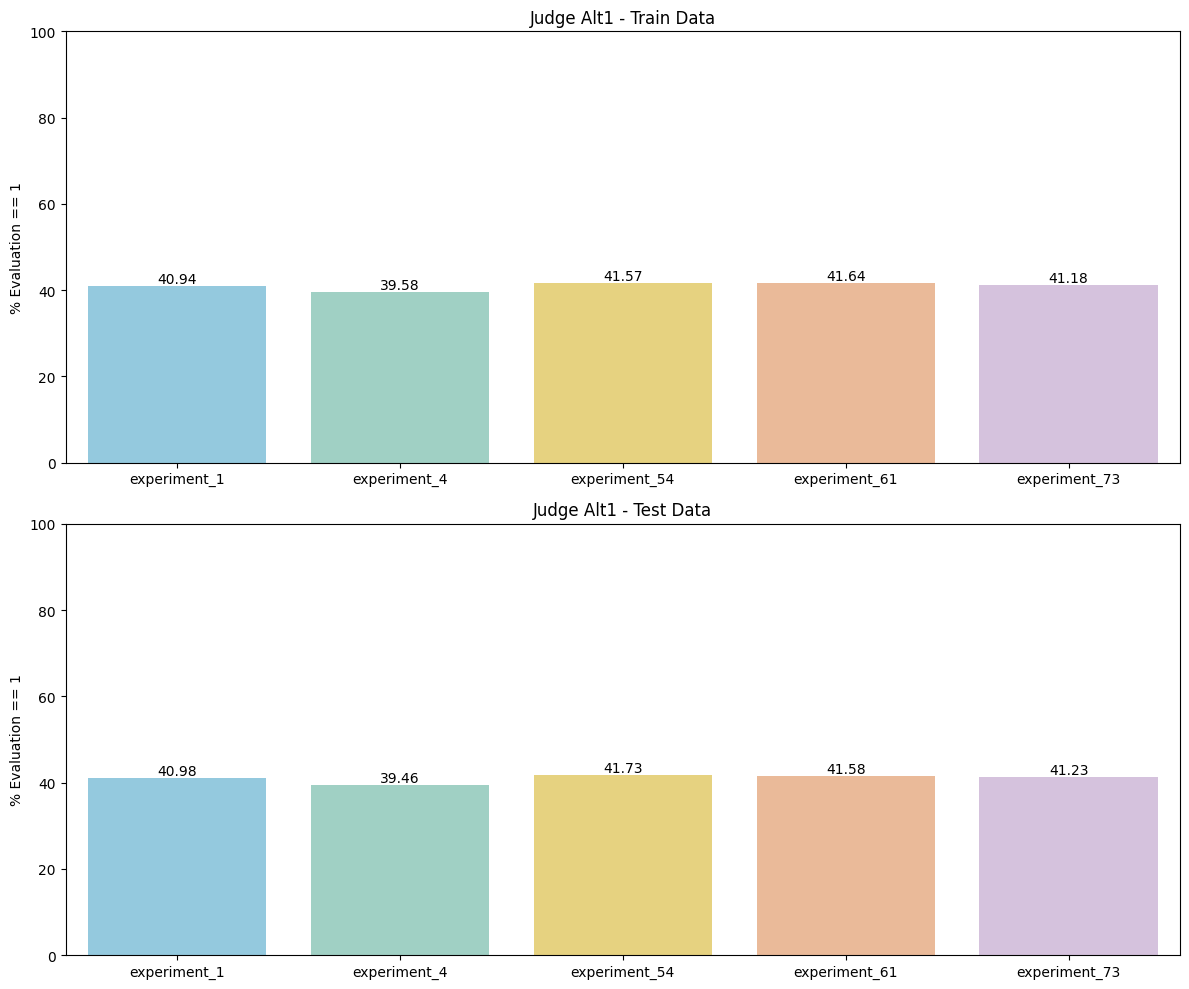

In [6]:
# Judge Analysis - % of evaluation == 1 for train and test
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Prepare data for train split
train_data = []
for exp in EXPERIMENTS:
    _exp = alt1_train.filter(pl.col("experiment") == exp)
    pct = (_exp.filter(pl.col("evaluation") == 1).height / _exp.height) * 100
    train_data.append({"experiment": exp, "percentage": pct})
train_df = pl.DataFrame(train_data)

# Plot train data
pastel_colors = ["#87CEEB", "#98D8C8", "#F7DC6F", "#F8B88B", "#D7BDE2"]  # Pastel colors
sns.barplot(data=train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
axes[0].set_title("Judge Alt1 - Train Data")
axes[0].set_ylabel("% Evaluation == 1")
axes[0].set_ylim(0, 100)
axes[0].set_xlabel("")

# Add value labels on top of bars
for patch in axes[0].patches:
    height = patch.get_height()
    axes[0].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

# Prepare data for test split
test_data = []
for exp in EXPERIMENTS:
    _exp = alt1_test.filter(pl.col("experiment") == exp)
    pct = (_exp.filter(pl.col("evaluation") == 1).height / _exp.height) * 100
    test_data.append({"experiment": exp, "percentage": pct})
test_df = pl.DataFrame(test_data)

# Plot test data
sns.barplot(data=test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])
axes[1].set_title("Judge Alt1 - Test Data")
axes[1].set_ylabel("% Evaluation == 1")
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("")

# Add value labels on top of bars
for patch in axes[1].patches:
    height = patch.get_height()
    axes[1].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1013027/778742141.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
/tmp/ipykernel_1013027/778742141.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])


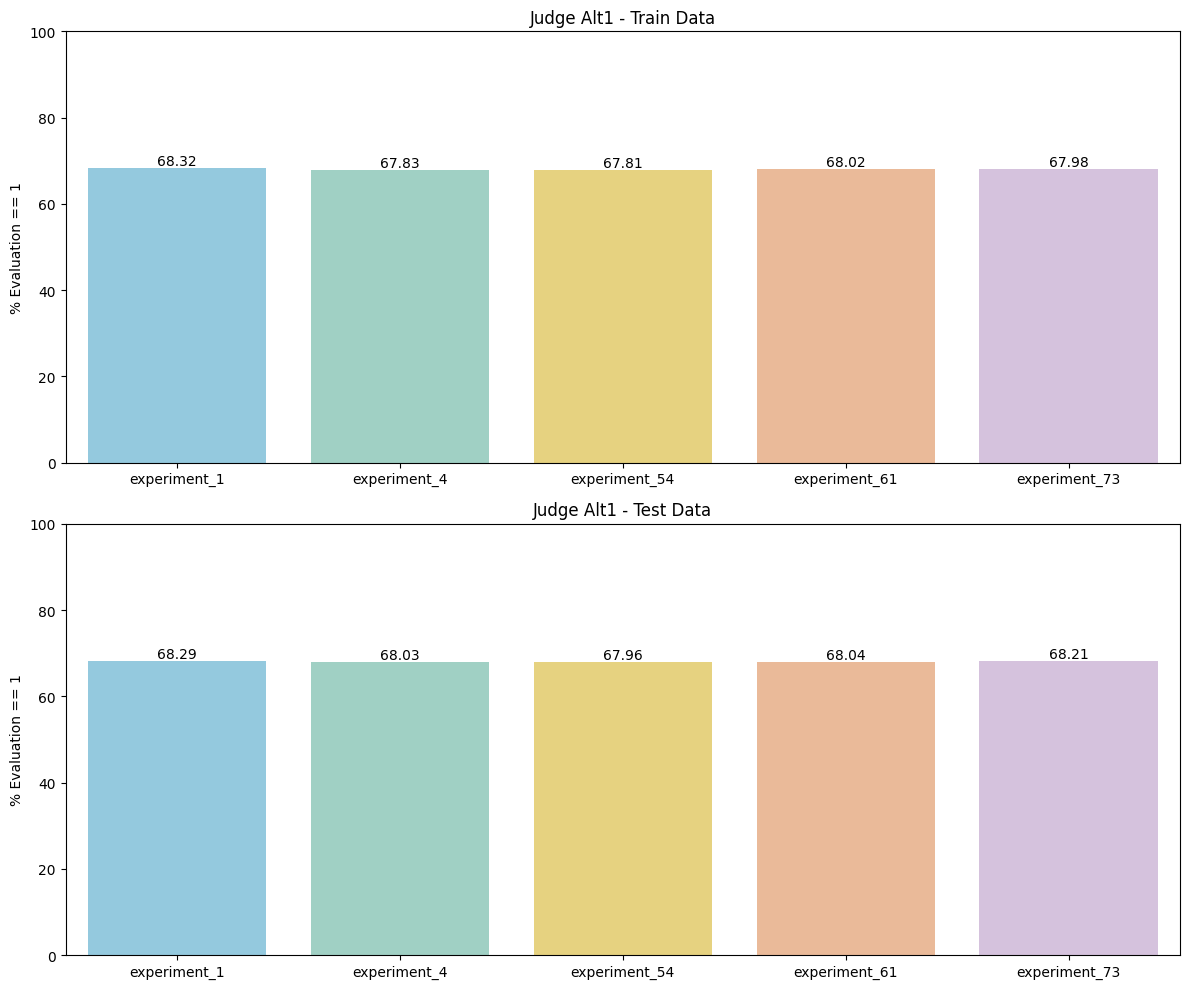

In [6]:
# Judge Analysis - % of evaluation == 1 for train and test
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Prepare data for train split
train_data = []
for exp in EXPERIMENTS:
    _exp = alt2_train.filter(pl.col("experiment") == exp)
    pct = (_exp.filter(pl.col("evaluation") == 1).height / _exp.height) * 100
    train_data.append({"experiment": exp, "percentage": pct})
train_df = pl.DataFrame(train_data)

# Plot train data
pastel_colors = ["#87CEEB", "#98D8C8", "#F7DC6F", "#F8B88B", "#D7BDE2"]  # Pastel colors
sns.barplot(data=train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
axes[0].set_title("Judge Alt1 - Train Data")
axes[0].set_ylabel("% Evaluation == 1")
axes[0].set_ylim(0, 100)
axes[0].set_xlabel("")

# Add value labels on top of bars
for patch in axes[0].patches:
    height = patch.get_height()
    axes[0].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

# Prepare data for test split
test_data = []
for exp in EXPERIMENTS:
    _exp = alt2_test.filter(pl.col("experiment") == exp)
    pct = (_exp.filter(pl.col("evaluation") == 1).height / _exp.height) * 100
    test_data.append({"experiment": exp, "percentage": pct})
test_df = pl.DataFrame(test_data)

# Plot test data
sns.barplot(data=test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])
axes[1].set_title("Judge Alt1 - Test Data")
axes[1].set_ylabel("% Evaluation == 1")
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("")

# Add value labels on top of bars
for patch in axes[1].patches:
    height = patch.get_height()
    axes[1].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Training Models

In [ ]:
X_alt1_train, y_alt1_train = get_train_sets(df, "alt1")
alt1_models = []



with tqdm(total=5 * 500, desc="Training models") as pbar:
    for i in range(5):
        _alt1_arr = []
        for j in range(500):
            # Alt1 model
            X_alt1 = X_alt1_train[i][j]
            y_alt1 = y_alt1_train[i][j].ravel()
            
            if best_params["judge"][i][j] is None:
                _alt1_arr.append(None)
            else:
                model_alt1 = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                model_alt1.fit(X_alt1, y_alt1)
                _alt1_arr.append(model_alt1)
           
            


            
            pbar.update(1)
        
        alt1_models.append(_alt1_arr)
        alt2_models.append(_alt2_arr)

del X_alt1_train, y_alt1_train, X_alt2_train, y_alt2_train

Training models: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [04:10<00:00,  9.97it/s]


In [15]:
for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt1_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt1_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt2_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt2_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt1_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt1_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt2_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt2_bias.pt")


### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    alt1_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/alt1/"
    alt2_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/alt2/"
    os.makedirs(alt2_path, exist_ok=True)
    os.makedirs(alt1_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt1_models[exp]]), f"{alt1_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in alt2_models[exp]]), f"{alt2_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt1_models[exp]]), f"{alt1_path}/0_499_bias.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt2_models[exp]]), f"{alt2_path}/0_499_bias.pt")

/tmp/ipykernel_1013027/537923468.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt1_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt1_bias.pt")
/tmp/ipykernel_1013027/537923468.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in alt2_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/alt2_bias.pt")
/tmp/ipykernel_1013027/537923468.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensu

In [11]:
LOAD = True
if LOAD:
    alt1_models = load_logistic_models_for_subfolder("judge", "alt1_weights.pt", "alt1_bias.pt", experiments=EXPERIMENTS)
    alt2_models = load_logistic_models_for_subfolder("judge", "alt2_weights.pt", "alt2_bias.pt", experiments=EXPERIMENTS)

In [13]:
X_alt1_test, y_alt1_test = get_test_sets(df, "alt1")
X_alt2_test, y_alt2_test = get_test_sets(df, "alt2")


_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}


for i in range(5):
    for j in range(500):
        
        alt1_lr = alt1_models[i][j]
        if alt1_lr is not None:

            _x = X_alt1_test[i][j]
            _y = y_alt1_test[i][j].ravel()
            score = roc_auc_score(_y, alt1_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("alt1")
            _eval_df["auc"].append(score)

        alt2_lr = alt2_models[i][j]
        if alt2_lr is not None:
            _x = X_alt2_test[i][j]
            _y = y_alt2_test[i][j].ravel()
            score = roc_auc_score(_y, alt2_lr.predict_proba(_x)[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("alt2")
            _eval_df["auc"].append(score)



del X_alt1_test, y_alt1_test, X_alt2_test, y_alt2_test
gc.collect()

511

In [15]:
eval_df = pl.DataFrame(_eval_df)    
eval_df.filter(pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean().alias("mean_auc"), pl.col("auc").std().alias("std_auc"))

type,mean_auc,std_auc
str,f64,f64
"""alt2""",0.555232,0.06655
"""alt1""",0.590805,0.082759


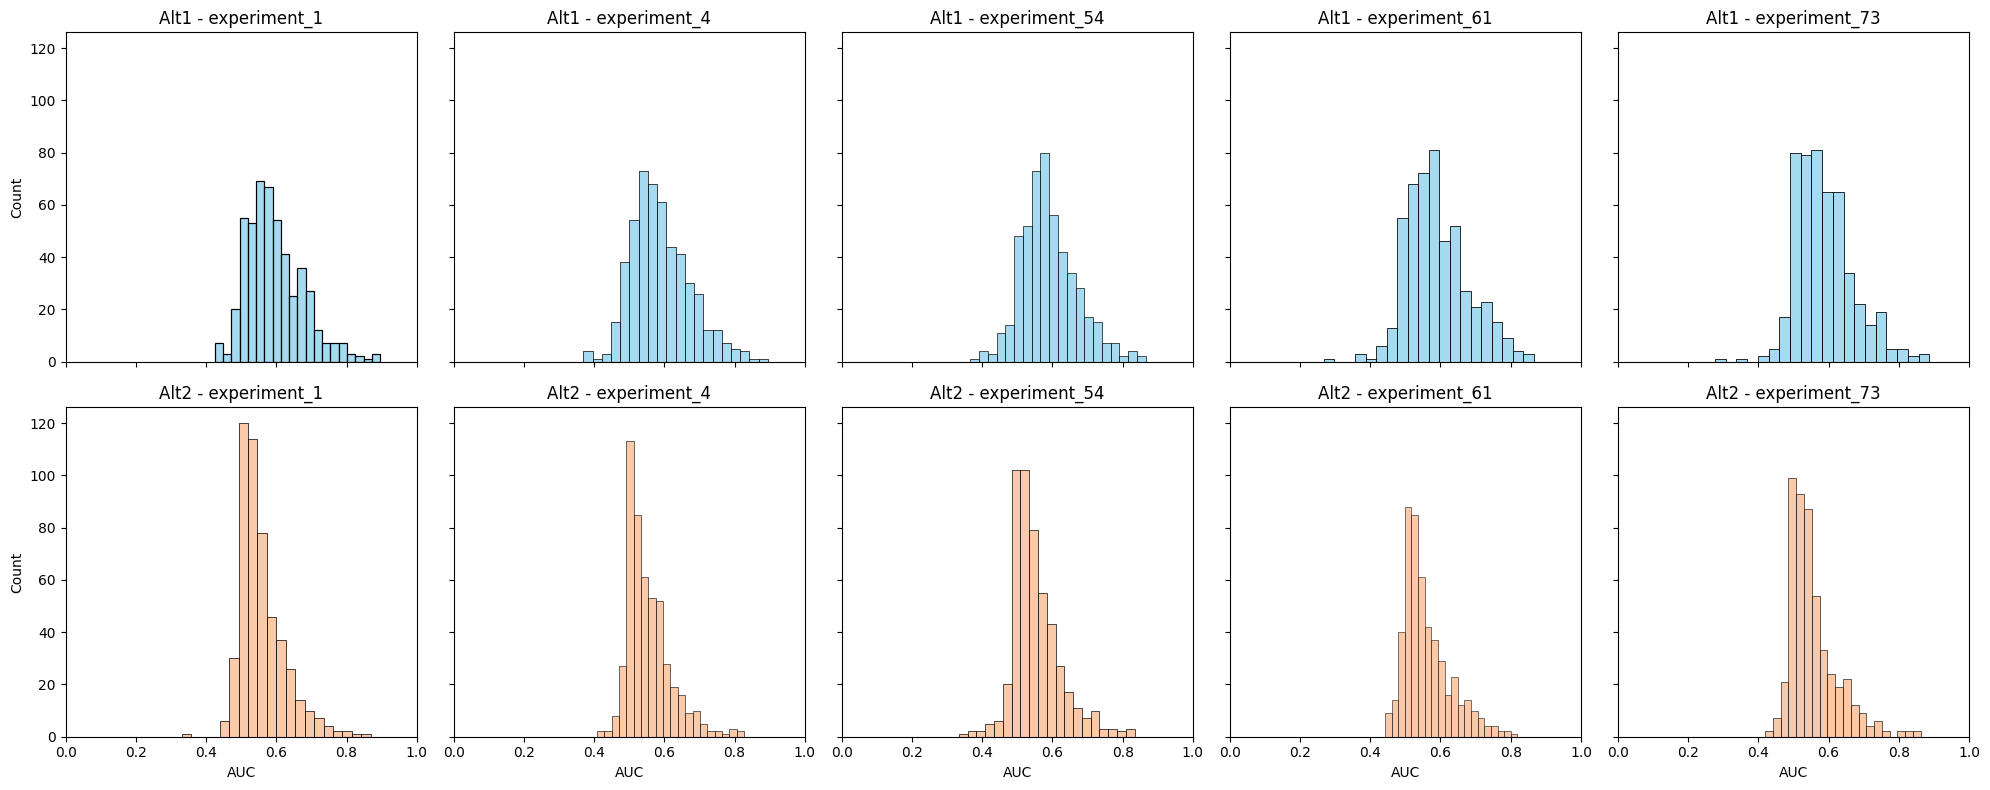

In [17]:
# Plot AUC histograms per type/experiment using existing eval_df (Polars)
import seaborn as sns
import matplotlib.pyplot as plt

eval_df = pl.DataFrame(_eval_df)    
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
color_map = {"alt1": "#87CEEB", "alt2": "#F8B88B"}  # Pastel blue, pastel orange

for row, t in enumerate(["alt1", "alt2"]):
    for col, exp in enumerate(EXPERIMENTS):
        subset = eval_df.filter((pl.col("type") == t) & (pl.col("experiment") == exp))
        sns.histplot(data=subset.to_pandas(), x="auc", bins=20, color=color_map[t], ax=axes[row, col])
        axes[row, col].set_title(f"{t.capitalize()} - {exp}")
        axes[row, col].set_xlim(0, 1)
        if col == 0:
            axes[row, col].set_ylabel("Count")
        else:
            axes[row, col].set_ylabel("")
        axes[row, col].set_xlabel("AUC")

plt.tight_layout()
plt.show()

### Text Generation Results

In [16]:
wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = True
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            if "alt" in file:
                print(f"Processing {file} for experiment {exp}...")
                dfs_generations.append(calculate_agg_metric(
                    metrics=["rouge_l"],
                    generation_path=f"runs/{exp}/generations/{file}",
                    reference_path=questions_path    ,
                    saving_path=None            
                )
                .with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(file.split('.')[0]).alias("model"),
                ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/alternative_inputs.feather")
else:
    generations_results = pl.read_ipc("generation_results/alternative_inputs.feather")

In [17]:
generations_results.group_by("model").agg(pl.col("mean").mean(), pl.col("mean").std().alias("std"))

model,mean,std
str,f64,f64
"""alt1""",0.410275,0.435703
"""alt2""",0.40768,0.435341


In [20]:
generations_results.filter(pl.col("mean")==1).group_by("model").agg(pl.count())

/tmp/ipykernel_1024236/4250346604.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  generations_results.filter(pl.col("mean")==1).group_by("model").agg(pl.count())


model,count
str,u32
"""alt2""",716
"""alt1""",716


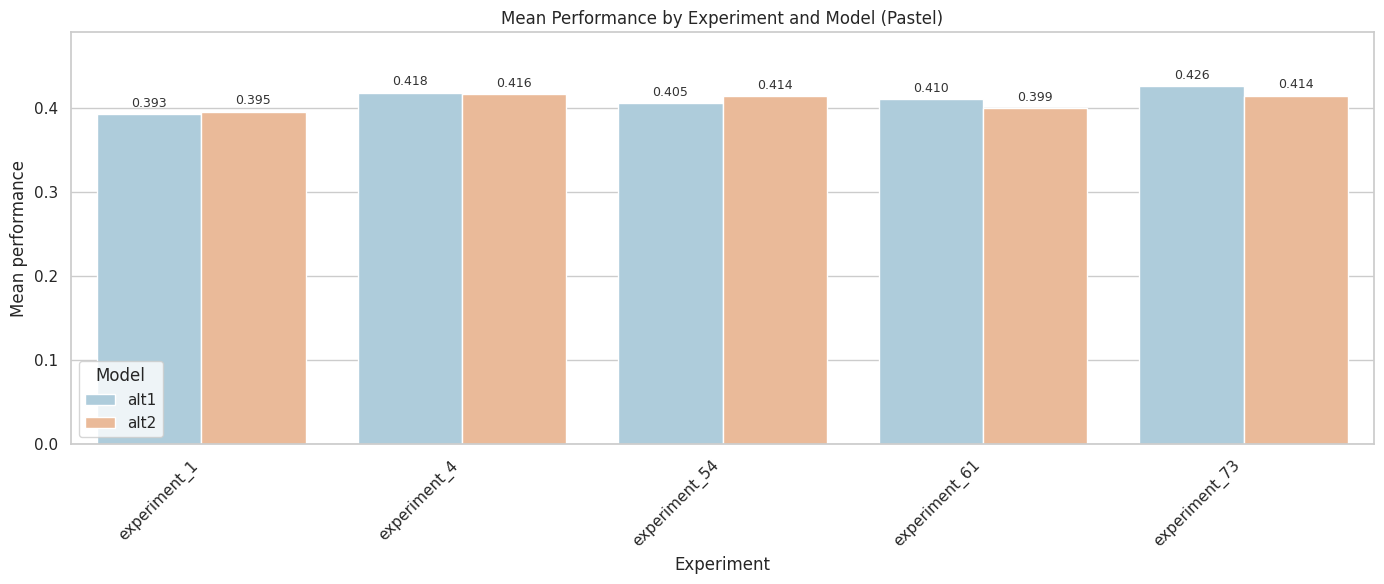

In [19]:
# Ensure the aggregated column is named `mean`
_df = generations_results.group_by(["experiment", "model"]).agg(pl.col("mean").mean())

_cols = _df.columns
if "mean" in _cols:
    df_plot = _df.rename({"mean": "mean"})
elif "mean_mean" in _cols:
    df_plot = _df.rename({"mean_mean": "mean"})
else:
    # Fallback: assume third column is the aggregated mean
    score_col = [c for c in _cols if c not in ("experiment", "model")][0]
    df_plot = _df.rename({score_col: "mean"})

# Convert to pandas for seaborn
_df_pd = df_plot.to_pandas()

# Limit to requested categories to ensure palette mapping works
wanted_models = ["alt1", "alt2"]
_df_pd = _df_pd[_df_pd["model"].isin(wanted_models)]

# Pastel palette mapping
palette = {
    "alt1": "#a6cee3",  # pastel blue
    "alt2": "#F8B88B",  # pastel orange
}

# Order experiments ascending
order_experiments = sorted(_df_pd["experiment"].unique())
hue_order = wanted_models

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=_df_pd,
    x="experiment",
    y="mean",
    hue="model",
    palette=palette,
    order=order_experiments,
    hue_order=hue_order,
)

plt.title("Mean Performance by Experiment and Model (Pastel)")
plt.xlabel("Experiment")
plt.ylabel("Mean performance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Show numeric labels above bars
try:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, color="#333")
except Exception:
    # Fallback for older matplotlib versions
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{height:.3f}",
                    (patch.get_x() + patch.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color="#333",
                    xytext=(0, 3), textcoords='offset points')

# Small headroom for labels
if len(_df_pd):
    plt.ylim(0, _df_pd["mean"].max() * 1.15)

plt.tight_layout()
plt.show()

## EBM 

The training was performed inside "ebm' subfolder.

### Training

In [21]:


## Load models
judge_models = []
groundtruth_models = []

_judge = joblib.load("ebm/ebm_judge_models.pkl")
_groundtruth = joblib.load("ebm/ebm_groundtruth_models.pkl")


# Load per-experiment .pkl/.joblib files
for i in range(5):
    judge_models.append([])
    groundtruth_models.append([])
    for j in range(500):
        judge_models[i].append(_judge[i][j])
        groundtruth_models[i].append(_groundtruth[i][j])

del _judge, _groundtruth
    
    

### AUC-SCORE Evaluation

In [22]:
X_groundtruth_test, y_groundtruth_test = get_test_sets(df, "groundtruth")
X_judge_test, y_judge_test = get_test_sets(df, "judge")


_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}


for i in range(5):
    for j in range(500):
        
        judge_model = judge_models[i][j]
        if judge_model is not None:

            _x = X_judge_test[i][j]
            _y = y_judge_test[i][j].ravel()
            result = judge_model.predict_proba(_x)
            if result.shape[1] == 1:
                # Handle case where model predicts only one class
                result = np.hstack([1 - result, result])
            score = roc_auc_score(_y, result[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("judge")
            _eval_df["auc"].append(score)

        groundtruth_model = groundtruth_models[i][j]
        if groundtruth_model is not None:
            _x = X_groundtruth_test[i][j]
            _y = y_groundtruth_test[i][j].ravel()
            result = groundtruth_model.predict_proba(_x)
            if result.shape[1] == 1:
                # Handle case where model predicts only one class
                result = np.hstack([1 - result, result])
            score = roc_auc_score(_y, result[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("groundtruth")
            _eval_df["auc"].append(score)



del X_groundtruth_test, y_groundtruth_test, X_judge_test, y_judge_test
gc.collect()

/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarnin

0

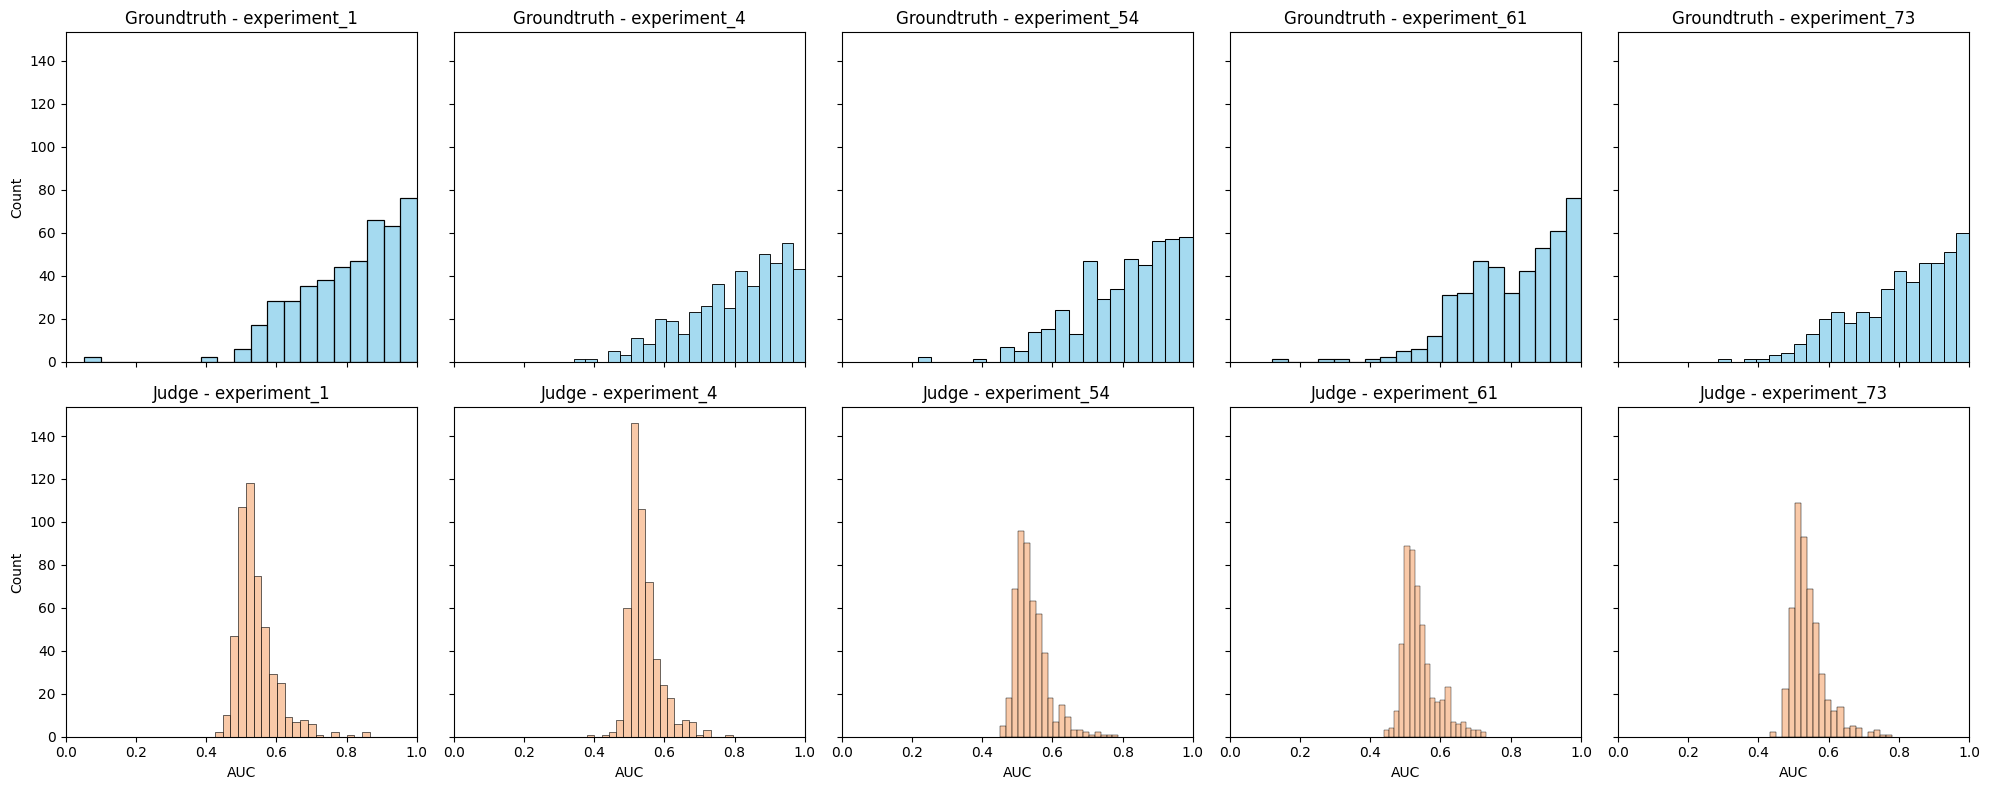

In [24]:
# Plot AUC histograms per type/experiment using existing eval_df (Polars)
import seaborn as sns
import matplotlib.pyplot as plt

eval_df = pl.DataFrame(_eval_df)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
color_map = {"groundtruth": "#87CEEB", "judge": "#F8B88B"}  # Pastel blue, pastel orange

for row, t in enumerate(["groundtruth", "judge"]):
    for col, exp in enumerate(EXPERIMENTS):
        subset = eval_df.filter((pl.col("type") == t) & (pl.col("experiment") == exp))
        sns.histplot(data=subset.to_pandas(), x="auc", bins=20, color=color_map[t], ax=axes[row, col])
        axes[row, col].set_title(f"{t.capitalize()} - {exp}")
        axes[row, col].set_xlim(0, 1)
        if col == 0:
            axes[row, col].set_ylabel("Count")
        else:
            axes[row, col].set_ylabel("")
        axes[row, col].set_xlabel("AUC")

plt.tight_layout()
plt.show()

In [25]:
eval_df.filter(pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean().alias("mean_auc"), pl.col("auc").std().alias("std_auc"))

type,mean_auc,std_auc
str,f64,f64
"""groundtruth""",0.808849,0.140072
"""judge""",0.541458,0.049623


In [50]:



for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.explain_global().data()["scores"][:100] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models[exp]]), f"weights/groundtruth/{EXPERIMENTS[exp]}/ebm_weights.pt")
    torch.save(torch.tensor([arr.explain_global().data()["scores"][:100] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/ebm_weights.pt")
  

### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    jg_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/ebm_judge/"
    gt_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/ebm_groundtruth/"
    os.makedirs(jg_path, exist_ok=True)
    os.makedirs(gt_path, exist_ok=True)

    torch.save(torch.tensor([arr.explain_global().data()["scores"][:100] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in groundtruth_models[exp]]), f"{gt_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.explain_global().data()["scores"][:100] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in judge_models[exp]]), f"{jg_path}/0_499_weights.pt")


/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2072: RuntimeWarning: invalid value encountered in add
  upper_bound = max(upper_bound, np.max(scores + errors))
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2166: RuntimeWarning: invalid value encountered in add
  upper_bounds = None if errors is None else list(model_graph + errors)
/home/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2189: RuntimeWarning: invalid value encountered in add
  "upper_bounds": None if errors is None else model_graph + errors,


### ROUGE-L Evaluation

In [28]:
wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = True
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            if "ebm" in file:
                print(f"Processing {file} for experiment {exp}...")
                dfs_generations.append(calculate_agg_metric(
                    metrics=["rouge_l"],
                    generation_path=f"runs/{exp}/generations/{file}",
                    reference_path=questions_path    ,
                    saving_path=None            
                )
                .with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(file.split('_')[1].split('.')[0]).alias("model"),
                ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/ebm.feather")
else:
    generations_results = pl.read_ipc("generation_results/ebm.feather")

In [27]:
generations_results.group_by("model").agg(pl.col("mean").mean(), pl.col("mean").std().alias("std"))

model,mean,std
str,f64,f64
"""groundtruth""",0.47467,0.439019
"""judge""",0.453646,0.440866


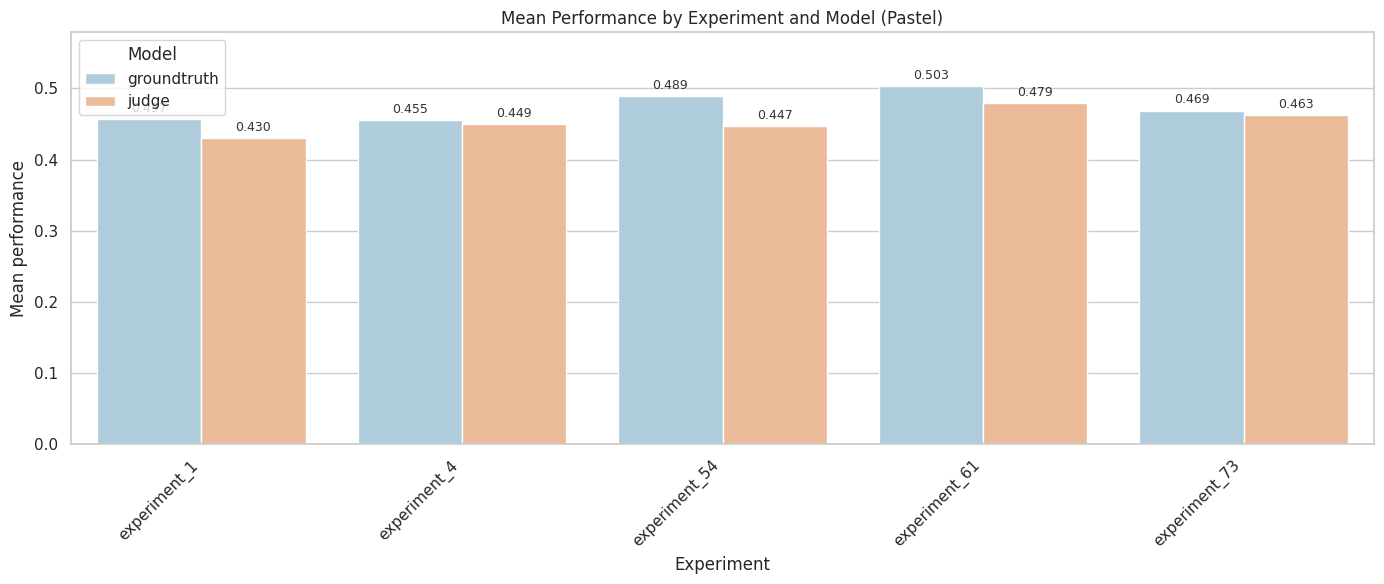

In [6]:
# Ensure the aggregated column is named `mean`
_df = generations_results.group_by(["experiment", "model"]).agg(pl.col("mean").mean())

_cols = _df.columns
if "mean" in _cols:
    df_plot = _df.rename({"mean": "mean"})
elif "mean_mean" in _cols:
    df_plot = _df.rename({"mean_mean": "mean"})
else:
    # Fallback: assume third column is the aggregated mean
    score_col = [c for c in _cols if c not in ("experiment", "model")][0]
    df_plot = _df.rename({score_col: "mean"})

# Convert to pandas for seaborn
_df_pd = df_plot.to_pandas()

# Limit to requested categories to ensure palette mapping works
wanted_models = ["groundtruth", "judge"]
_df_pd = _df_pd[_df_pd["model"].isin(wanted_models)]

# Pastel palette mapping
palette = {
    "groundtruth": "#a6cee3",  # pastel blue
    "judge": "#F8B88B",        # pastel yellow
}

# Order experiments ascending
order_experiments = sorted(_df_pd["experiment"].unique())
hue_order = wanted_models

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=_df_pd,
    x="experiment",
    y="mean",
    hue="model",
    palette=palette,
    order=order_experiments,
    hue_order=hue_order,
)

plt.title("Mean Performance by Experiment and Model (Pastel)")
plt.xlabel("Experiment")
plt.ylabel("Mean performance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Show numeric labels above bars
try:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, color="#333")
except Exception:
    # Fallback for older matplotlib versions
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{height:.3f}",
                    (patch.get_x() + patch.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color="#333",
                    xytext=(0, 3), textcoords='offset points')

# Small headroom for labels
if len(_df_pd):
    plt.ylim(0, _df_pd["mean"].max() * 1.15)

plt.tight_layout()
plt.show()

## Voting Binary Judge

### Dataset Distribution Analysis

In [5]:
voting_train = df.filter((pl.col("subfolder") == "voting_alt1") & (pl.col("split") == "train"))
voting_test = df.filter((pl.col("subfolder") == "voting_alt1") & (pl.col("split") == "test"))

/tmp/ipykernel_4083490/2568555494.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
/tmp/ipykernel_4083490/2568555494.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])


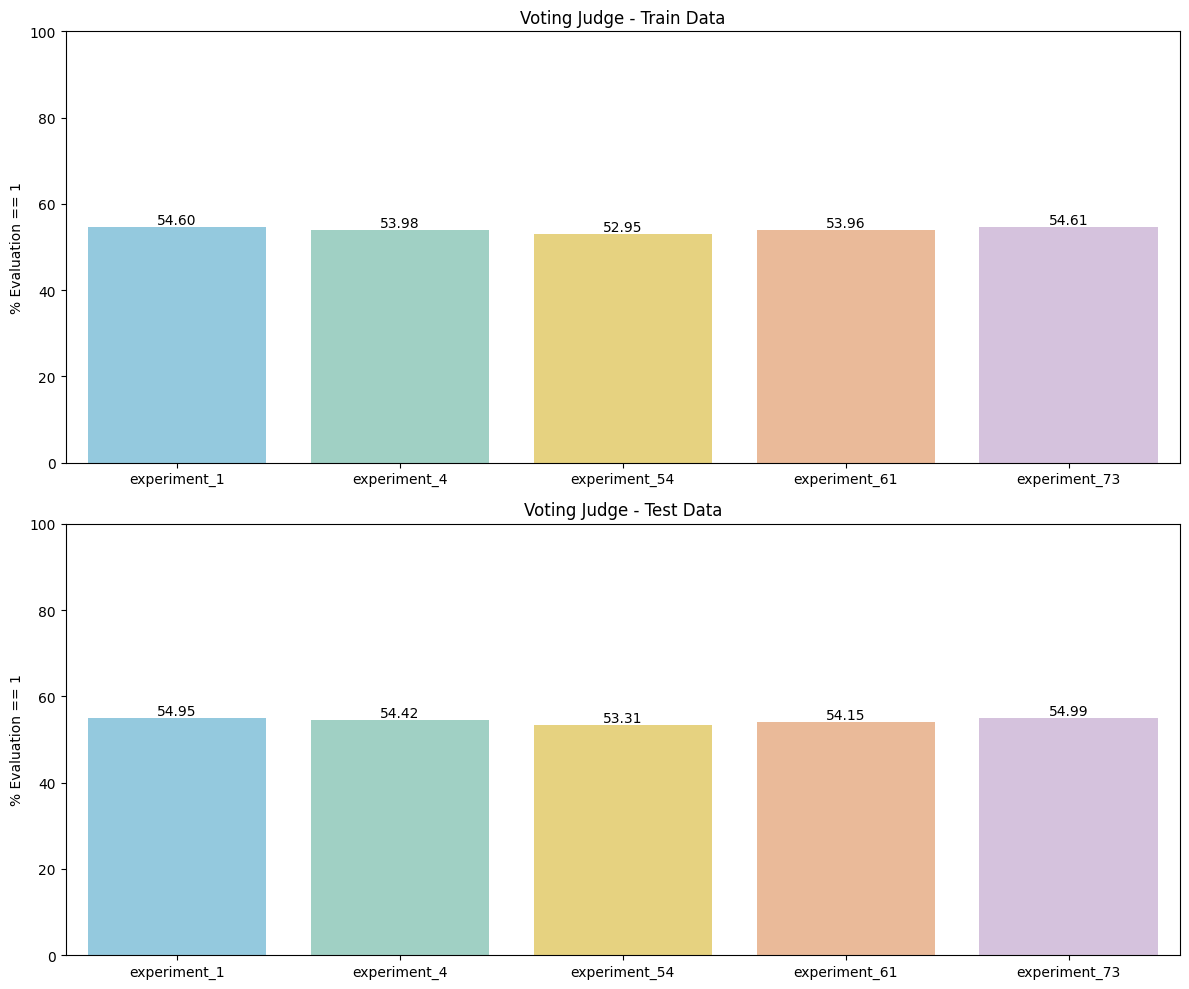

In [6]:
# Judge Analysis - % of evaluation == 1 for train and test
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Prepare data for train split
train_data = []
for exp in EXPERIMENTS:
    _exp = voting_train.filter(pl.col("experiment") == exp)
    pct = (_exp.filter(pl.col("evaluation") == 1).height / _exp.height) * 100
    train_data.append({"experiment": exp, "percentage": pct})
train_df = pl.DataFrame(train_data)

# Plot train data
pastel_colors = ["#87CEEB", "#98D8C8", "#F7DC6F", "#F8B88B", "#D7BDE2"]  # Pastel colors
sns.barplot(data=train_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[0])
axes[0].set_title("Voting Judge - Train Data")
axes[0].set_ylabel("% Evaluation == 1")
axes[0].set_ylim(0, 100)
axes[0].set_xlabel("")

# Add value labels on top of bars
for patch in axes[0].patches:
    height = patch.get_height()
    axes[0].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

# Prepare data for test split
test_data = []
for exp in EXPERIMENTS:
    _exp = voting_test.filter(pl.col("experiment") == exp)
    pct = (_exp.filter(pl.col("evaluation") == 1).height / _exp.height) * 100
    test_data.append({"experiment": exp, "percentage": pct})
test_df = pl.DataFrame(test_data)

# Plot test data
sns.barplot(data=test_df.to_pandas(), x="experiment", y="percentage", palette=pastel_colors, ax=axes[1])
axes[1].set_title("Voting Judge - Test Data")
axes[1].set_ylabel("% Evaluation == 1")
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("")

# Add value labels on top of bars
for patch in axes[1].patches:
    height = patch.get_height()
    axes[1].text(patch.get_x() + patch.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Training Models

In [12]:
X_voting_train,y_voting_train = get_train_sets(df, "voting_alt1")
voting_models = []



with tqdm(total=5 * 500, desc="Training models") as pbar:
    for i in range(5):
        _voting_arr = []
        for j in range(500):
            # Voting model
            X_voting = X_voting_train[i][j]
            y_voting = y_voting_train[i][j].ravel()
            
            if best_params["judge"][i][j] is None:
                _voting_arr.append(None)
            else:
                model_voting = LogisticRegression(**best_params["judge"][i][j], max_iter=1000, random_state=42)
                try:
                    model_voting.fit(X_voting, y_voting)
                    _voting_arr.append(model_voting)
                except Exception as e:
                    print(f"Error training voting model for experiment {EXPERIMENTS[i]}, index {j}: {e}")
                    _voting_arr.append(None)
            
            pbar.update(1)
        
        voting_models.append(_voting_arr)

del X_voting_train, y_voting_train

Training models:   0%|                                                                                                                                                                         | 0/2500 [00:00<?, ?it/s]/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarni

Error training voting model for experiment experiment_4, index 172: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1


/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
Training models:  27%|███████████████████████████████████████████▍                                                  

In [16]:
for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in voting_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/voting.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in voting_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/voting_bias.pt")


### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    voting_path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/voting/"
    os.makedirs(voting_path, exist_ok=True)

    torch.save(torch.tensor([arr.coef_[0] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in voting_models[exp]]), f"{voting_path}/0_499_weights.pt")
    torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in voting_models[exp]]), f"{voting_path}/0_499_bias.pt")


/tmp/ipykernel_4083490/3464341385.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in voting_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/voting_bias.pt")
/tmp/ipykernel_4083490/3464341385.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  torch.save(torch.tensor([arr.intercept_ if arr is not None else np.array([[1]]) for arr in voting_models[exp]]), f"{voting_path}/0_499_bias.pt")


In [5]:
LOAD = True
if LOAD:
    voting_models = load_logistic_models_for_subfolder("judge", "voting.pt", "voting_bias.pt", experiments=EXPERIMENTS)

In [6]:
## Loading EBM Models
ebm_voting_models = []

_ebm_voting = joblib.load("ebm/ebm_voting_models.pkl")



# Load per-experiment .pkl/.joblib files
for i in range(5):
    ebm_voting_models.append([])
    for j in range(500):
        ebm_voting_models[i].append(_ebm_voting[i][j])

del _ebm_voting
    

In [11]:
for exp in range(len(EXPERIMENTS)):
    torch.save(torch.tensor([arr.explain_global().data()["scores"][:100] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in ebm_voting_models[exp]]), f"weights/judge/{EXPERIMENTS[exp]}/ebm_voting_weights.pt")
  

### saving for datamodels generations
for exp in range(len(EXPERIMENTS)):
    path = f"runs/{EXPERIMENTS[exp]}/datamodels/models/ebm_voting/"
    os.makedirs(path, exist_ok=True)

    torch.save(torch.tensor([arr.explain_global().data()["scores"][:100] if arr is not None else (np.arange(100) < 16).astype(float64) for arr in ebm_voting_models[exp]]), f"{path}/0_499_weights.pt")


/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2072: RuntimeWarning: invalid value encountered in add
  upper_bound = max(upper_bound, np.max(scores + errors))
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2166: RuntimeWarning: invalid value encountered in add
  upper_bounds = None if errors is None else list(model_graph + errors)
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/interpret/glassbox/_ebm/_ebm.py:2189: RuntimeWarning: invalid value encountered in add
  "upper_bounds": None if errors is None else model_graph + errors,


In [7]:
X_voting_test, y_voting_test = get_test_sets(df, "voting_alt1")


_eval_df = {
    "experiment": [],
    "type": [],
    "auc": [],
}


for i in range(5):
    for j in range(500):
        
        voting_lr = voting_models[i][j]
        ebm_model = ebm_voting_models[i][j]

        if voting_lr is not None:

            _x = X_voting_test[i][j]
            _y = y_voting_test[i][j].ravel()
            score = roc_auc_score(_y, voting_lr.predict_proba(_x)[:, 1])


            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("voting_lr")
            _eval_df["auc"].append(score)

            result = ebm_model.predict_proba(_x)
            if result.shape[1] == 1:
                # Handle case where model predicts only one class
                result = np.hstack([1 - result, result])
            score = roc_auc_score(_y, result[:, 1])

            _eval_df["experiment"].append(EXPERIMENTS[i])
            _eval_df["type"].append("voting_ebm")
            _eval_df["auc"].append(score)

        



del X_voting_test, y_voting_test
gc.collect()

/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/users/caio.rhoden/miniconda3/envs/nq/lib/python3.11/site-packages/sklearn/metrics/_ranking

0

In [8]:
eval_df = pl.DataFrame(_eval_df)    
eval_df = pl.DataFrame(_eval_df)    
eval_df.filter(pl.col("auc").is_not_nan()).group_by("type").agg(pl.col("auc").mean().alias("mean_auc"), pl.col("auc").std().alias("std_auc"))

type,mean_auc,std_auc
str,f64,f64
"""voting_ebm""",0.582911,0.101309
"""voting_lr""",0.606436,0.105119


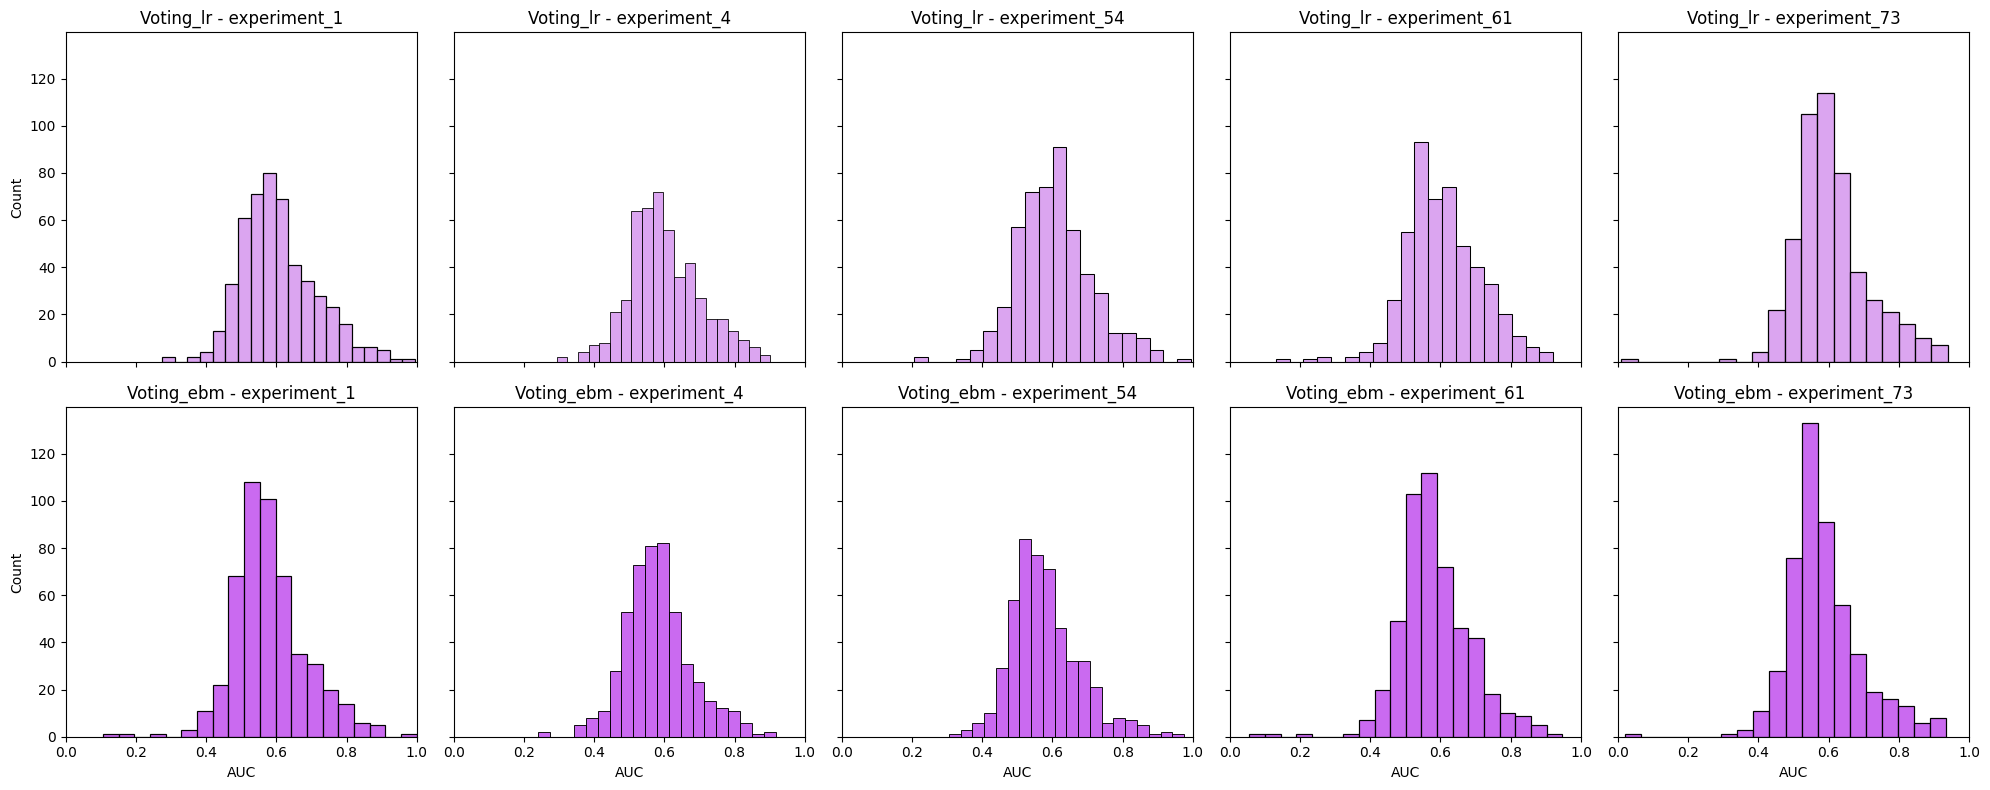

In [10]:
# Plot AUC histograms per type/experiment using existing eval_df (Polars)
import seaborn as sns
import matplotlib.pyplot as plt

eval_df = pl.DataFrame(_eval_df)    
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
color_map = {"voting_lr": "#CF87EB", "voting_ebm": "#B938EC"}  # Pastel blue, pastel orange

for row, t in enumerate(["voting_lr", "voting_ebm"]):
    for col, exp in enumerate(EXPERIMENTS):
        subset = eval_df.filter((pl.col("type") == t) & (pl.col("experiment") == exp))
        sns.histplot(data=subset.to_pandas(), x="auc", bins=20, color=color_map[t], ax=axes[row, col])
        axes[row, col].set_title(f"{t.capitalize()} - {exp}")
        axes[row, col].set_xlim(0, 1)
        if col == 0:
            axes[row, col].set_ylabel("Count")
        else:
            axes[row, col].set_ylabel("")
        axes[row, col].set_xlabel("AUC")

plt.tight_layout()
plt.show()

### Text Generation Results

In [ ]:
wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = False
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            if file.startswith("voting"):
                print(f"Processing {file} for experiment {exp}...")
                dfs_generations.append(calculate_agg_metric(
                    metrics=["rouge_l"],
                    generation_path=f"runs/{exp}/generations/{file}",
                    reference_path=questions_path    ,
                    saving_path=None            
                )
                .with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(file.split('.')[0]).alias("model"),
                ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/voting.feather")
else:
    generations_results = pl.read_ipc("generation_results/voting.feather")

Processing voting.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing voting.json for experiment experiment_4...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing voting.json for experiment experiment_54...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing voting.json for experiment experiment_61...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing voting.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [13]:
wiki = pl.read_ipc(f"../../data/wiki_dump2018_nq_open/processed/wiki.feather")
gold = pl.read_ipc(f"../../data/nq_open_gold/processed/dev.feather")

LOAD = False
if not LOAD:
    dfs_generations = []
    for exp in EXPERIMENTS:
        questions_path = f"runs/{exp}/questions.feather"
        for file in os.listdir(f"runs/{exp}/generations"):
            if file.startswith("ebm_voting"):
                print(f"Processing {file} for experiment {exp}...")
                dfs_generations.append(calculate_agg_metric(
                    metrics=["rouge_l"],
                    generation_path=f"runs/{exp}/generations/{file}",
                    reference_path=questions_path    ,
                    saving_path=None            
                )
                .with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(file.split('.')[0]).alias("model"),
                ]))

    generations_results = pl.concat(dfs_generations)
    generations_results.write_ipc("generation_results/ebm_voting.feather")
else:
    generations_results = pl.read_ipc("generation_results/ebm_voting.feather")

Processing ebm_voting.json for experiment experiment_1...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing ebm_voting.json for experiment experiment_4...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing ebm_voting.json for experiment experiment_54...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing ebm_voting.json for experiment experiment_61...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing ebm_voting.json for experiment experiment_73...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


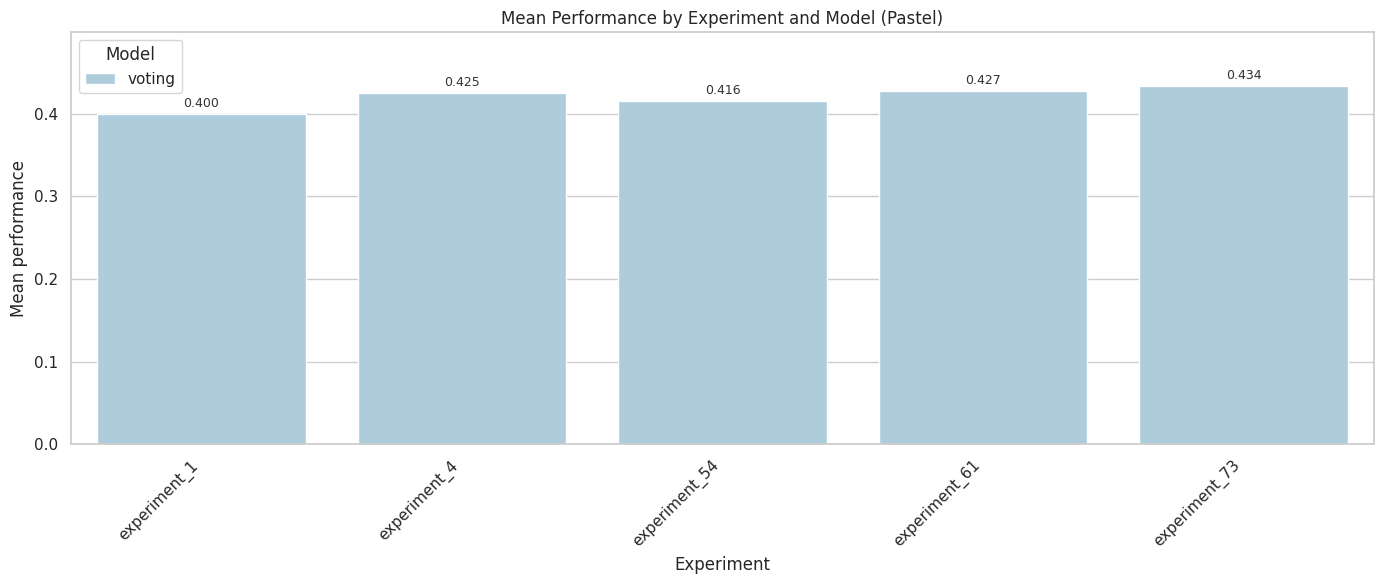

In [29]:
# Ensure the aggregated column is named `mean`
_df = generations_results.group_by(["experiment", "model"]).agg(pl.col("mean").mean())

_cols = _df.columns
if "mean" in _cols:
    df_plot = _df.rename({"mean": "mean"})
elif "mean_mean" in _cols:
    df_plot = _df.rename({"mean_mean": "mean"})
else:
    # Fallback: assume third column is the aggregated mean
    score_col = [c for c in _cols if c not in ("experiment", "model")][0]
    df_plot = _df.rename({score_col: "mean"})

# Convert to pandas for seaborn
_df_pd = df_plot.to_pandas()

# Limit to requested categories to ensure palette mapping works
wanted_models = ["voting"]
_df_pd = _df_pd[_df_pd["model"].isin(wanted_models)]

# Pastel palette mapping
palette = {
    "voting": "#a6cee3",  # pastel blue
}

# Order experiments ascending
order_experiments = sorted(_df_pd["experiment"].unique())
hue_order = wanted_models

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=_df_pd,
    x="experiment",
    y="mean",
    hue="model",
    palette=palette,
    order=order_experiments,
    hue_order=hue_order,
)

plt.title("Mean Performance by Experiment and Model (Pastel)")
plt.xlabel("Experiment")
plt.ylabel("Mean performance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Show numeric labels above bars
try:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, color="#333")
except Exception:
    # Fallback for older matplotlib versions
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{height:.3f}",
                    (patch.get_x() + patch.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color="#333",
                    xytext=(0, 3), textcoords='offset points')

# Small headroom for labels
if len(_df_pd):
    plt.ylim(0, _df_pd["mean"].max() * 1.15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1647604/3431117927.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Model")


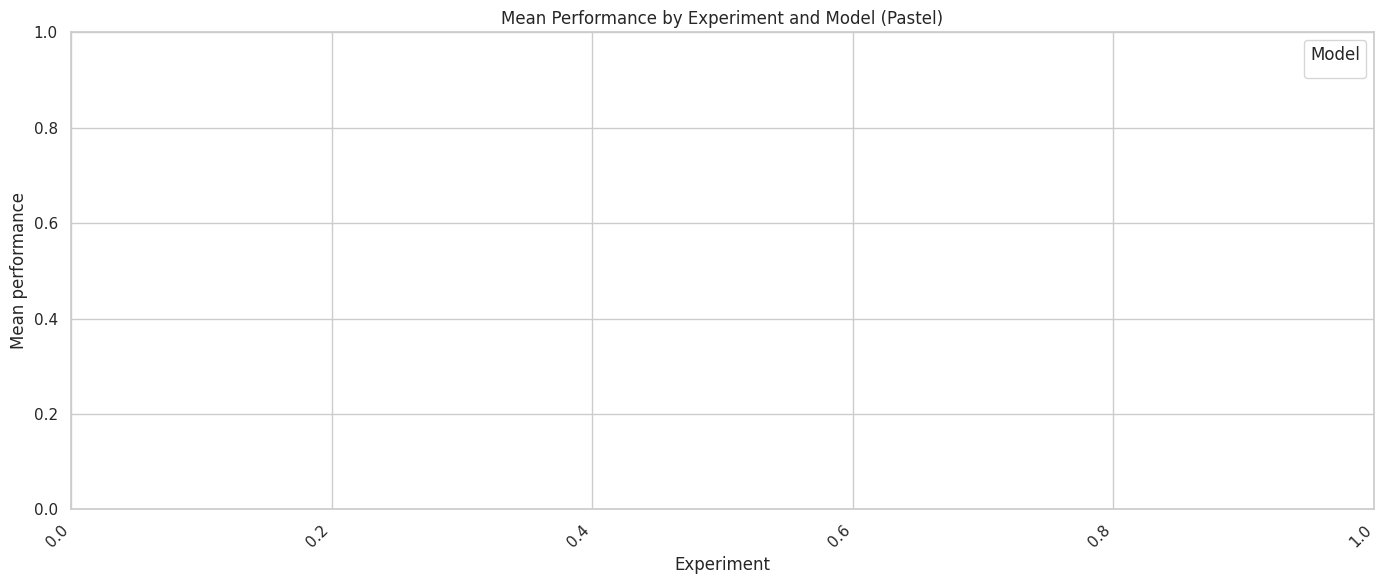

In [14]:

# Ensure the aggregated column is named `mean`
_df = generations_results.group_by(["experiment", "model"]).agg(pl.col("mean").mean())

_cols = _df.columns
if "mean" in _cols:
    df_plot = _df.rename({"mean": "mean"})
elif "mean_mean" in _cols:
    df_plot = _df.rename({"mean_mean": "mean"})
else:
    # Fallback: assume third column is the aggregated mean
    score_col = [c for c in _cols if c not in ("experiment", "model")][0]
    df_plot = _df.rename({score_col: "mean"})

# Convert to pandas for seaborn
_df_pd = df_plot.to_pandas()

# Limit to requested categories to ensure palette mapping works
wanted_models = ["voting"]
_df_pd = _df_pd[_df_pd["model"].isin(wanted_models)]

# Pastel palette mapping
palette = {
    "voting": "#a6cee3",  # pastel blue
}

# Order experiments ascending
order_experiments = sorted(_df_pd["experiment"].unique())
hue_order = wanted_models

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=_df_pd,
    x="experiment",
    y="mean",
    hue="model",
    palette=palette,
    order=order_experiments,
    hue_order=hue_order,
)

plt.title("Mean Performance by Experiment and Model (Pastel)")
plt.xlabel("Experiment")
plt.ylabel("Mean performance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")

# Show numeric labels above bars
try:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, color="#333")
except Exception:
    # Fallback for older matplotlib versions
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(f"{height:.3f}",
                    (patch.get_x() + patch.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color="#333",
                    xytext=(0, 3), textcoords='offset points')

# Small headroom for labels
if len(_df_pd):
    plt.ylim(0, _df_pd["mean"].max() * 1.15)

plt.tight_layout()
plt.show()

In [30]:
generations_results.group_by("model").agg(pl.col("mean").mean(), pl.col("mean").std().alias("std"))

model,mean,std
str,f64,f64
"""voting""",0.420396,0.436064


In [15]:
generations_results.group_by("model").agg(pl.col("mean").mean(), pl.col("mean").std().alias("std"))

model,mean,std
str,f64,f64
"""ebm_voting""",0.438346,0.440426


## KL-Divergance Groundtruth vs Every other binary collection

In [12]:
import scipy.stats

# Compute distributions for each subfolder
distributions = {}
for subfolder in ["judge", "groundtruth", "alt1", "alt2", "voting_alt1"]:
    subset = df.filter(pl.col("subfolder") == subfolder)
    counts = subset.group_by("evaluation").agg(pl.count("evaluation").alias("count"))
    total = counts.select(pl.sum("count")).to_numpy()[0][0]
    p1 = counts.filter(pl.col("evaluation") == 1).select("count").to_numpy()[0][0] / total
    p0 = 1 - p1
    distributions[subfolder] = [p0, p1]

# Groundtruth distribution
groundtruth_dist = distributions["groundtruth"]

# Compute KL divergence for each subfolder compared to groundtruth
kl_divergences = {}
for subfolder in ["judge", "alt1", "alt2", "voting_alt1"]:
    kl = scipy.stats.entropy(distributions[subfolder], groundtruth_dist)
    kl_divergences[subfolder] = kl
    print(f"KL divergence of {subfolder} from groundtruth: {kl}")

KL divergence of judge from groundtruth: 0.018161609622297917
KL divergence of alt1 from groundtruth: 0.00539688731216649
KL divergence of alt2 from groundtruth: 0.14601610018585345
KL divergence of voting_alt1 from groundtruth: 0.033403579521629936
